## Mini Project — Exploratory Data Analysis on India's COVID-19 Data

# 🇮🇳 COVID-19 in India: State-wise Trends, Recovery & Vaccination Analysis

## 📌 Project Objective

This notebook analyses the COVID-19 pandemic in India using **NumPy, Pandas, Matplotlib, and Seaborn**.

The analysis is divided into two connected phases:

1. **First Wave (30 Jan 2020 – 6 Aug 2020)**
   - State-wise confirmed cases
   - Recoveries
   - Deaths
   - Recovery and mortality rates
   - State-wise trends

2. **Vaccination Rollout (15 Jan 2021 onward)**
   - Total vaccinations
   - Daily vaccination progress
   - Vaccination milestones
   - Cumulative vaccination growth

### 🎯 Key Questions

- Which states reported the highest number of COVID-19 cases?
- Which states had the highest recovery rates?
- How did deaths vary across states?
- Which states experienced the fastest growth?
- How did India's vaccination programme progress over time?
- What major trends can be observed from the first wave and subsequent vaccination rollout?

> **Important:** The case dataset ends on 6 August 2020, while vaccination data starts from January 2021. Therefore, vaccination data is analysed as a separate subsequent phase rather than directly comparing vaccination with first-wave cases.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

## Data

The case dataset contains daily state-wise COVID-19 information for India.

Source:
`imdevskp/covid-19-india-data`

Coverage:
**30 January 2020 – 6 August 2020**

In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


## 3. Initial Data Overview

In [3]:
print("Shape:", cases.shape)

Shape: (4692, 10)


In [4]:
# Check data types and non-null values
cases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4692 entries, 0 to 4691
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       4692 non-null   object 
 1   Name of State / UT         4692 non-null   object 
 2   Latitude                   4692 non-null   float64
 3   Longitude                  4692 non-null   float64
 4   Total Confirmed cases      4692 non-null   float64
 5   Death                      4692 non-null   object 
 6   Cured/Discharged/Migrated  4692 non-null   float64
 7   New cases                  4692 non-null   int64  
 8   New deaths                 4692 non-null   int64  
 9   New recovered              4692 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 366.7+ KB


In [5]:
# Statistical summary of numerical columns
cases.describe(include="all")

,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
count,4692,4692,4692.000000,4692.000000,4692.000000,4692,4692.000000,4692.000000,4692.0,4692.000000
unique,186,40,NaN,NaN,NaN,839,NaN,NaN,NaN,NaN
top,2020-06-06,Kerala,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
freq,35,186,NaN,NaN,NaN,1460,NaN,NaN,NaN,NaN
mean,NaN,NaN,23.185327,81.451837,11393.925192,NaN,6908.130648,418.643009,0.0,283.069054
std,NaN,NaN,6.635913,6.959475,37208.600846,NaN,23390.671258,1259.748923,0.0,947.925811
min,NaN,NaN,0.000000,0.000000,1.000000,NaN,0.000000,0.000000,0.0,-1.000000
25%,NaN,NaN,18.112400,76.271100,39.000000,NaN,9.000000,1.000000,0.0,0.000000
50%,NaN,NaN,23.940800,79.019300,619.000000,NaN,197.500000,26.000000,0.0,8.000000
75%,NaN,NaN,28.218000,85.313100,5233.000000,NaN,2736.000000,210.250000,0.0,119.000000


In [6]:
# Missing values in each column
cases.isnull().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [7]:
# Display all column names
cases.columns.tolist()

['Date',
 'Name of State / UT',
 'Latitude',
 'Longitude',
 'Total Confirmed cases',
 'Death',
 'Cured/Discharged/Migrated',
 'New cases',
 'New deaths',
 'New recovered']

## 4. Data Cleaning

In [8]:
# Rename columns with simple and consistent names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered"
]

# Display the new column names
cases.columns

Index(['date', 'state', 'lat', 'long', 'confirmed', 'deaths', 'cured',
       'new_cases', 'new_deaths', 'new_recovered'],
      dtype='object')

In [9]:
# Convert the date column into datetime format
cases["date"] = pd.to_datetime(cases["date"])

# Check the data type
cases["date"].dtype

dtype('<M8[ns]')

In [10]:
# Convert deaths into numeric values
# Invalid values are converted to NaN
cases["deaths"] = pd.to_numeric(
    cases["deaths"],
    errors="coerce"
)

# Replace missing values with 0
cases["deaths"] = cases["deaths"].fillna(0)

# Convert to integer
cases["deaths"] = cases["deaths"].astype(int)

In [11]:
# Convert confirmed and recovered cases into integers
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

In [12]:
# Check the number of missing values
cases.isnull().sum()

date             0
state            0
lat              0
long             0
confirmed        0
deaths           0
cured            0
new_cases        0
new_deaths       0
new_recovered    0
dtype: int64

In [13]:
# Count duplicate rows
print("Duplicate rows:", cases.duplicated().sum())

Duplicate rows: 0


In [14]:
# Create a dictionary to correct state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh"
}

# Replace inconsistent names
cases["state"] = cases["state"].replace(name_fix)

In [15]:
# Remove duplicate records for the same date and state
cases = cases.drop_duplicates(
    subset=["date", "state"]
)

In [16]:
# Sort the data by state and date
cases = cases.sort_values(
    ["state", "date"]
).reset_index(drop=True)

In [17]:
# Calculate active COVID-19 cases
# Active = Confirmed - Deaths - Recovered

cases["active"] = (
    cases["confirmed"]
    - cases["deaths"]
    - cases["cured"]
)

cases.head()

,date,state,lat,long,confirmed,deaths,cured,new_cases,new_deaths,new_recovered,active
0,2020-03-26,Andaman and Nicobar Islands,11.7401,92.6586,1,0,0,0,0,0,1
1,2020-03-27,Andaman and Nicobar Islands,11.7401,92.6586,1,0,0,0,0,0,1
2,2020-03-28,Andaman and Nicobar Islands,11.7401,92.6586,6,0,0,5,0,0,6
3,2020-03-29,Andaman and Nicobar Islands,11.7401,92.6586,9,0,0,3,0,0,9
4,2020-03-30,Andaman and Nicobar Islands,11.7401,92.6586,9,0,0,0,0,0,9


In [18]:
# Check the cleaned dataset
print("Dataset Shape:", cases.shape)

# Check unique state names
print("\nNumber of States/UTs:", cases["state"].nunique())

# Check data types
print("\nData Types:")
print(cases.dtypes)

# Check missing values again
print("\nMissing Values:")
print(cases.isnull().sum())

Dataset Shape: (4692, 11)

Number of States/UTs: 35

Data Types:
date             datetime64[ns]
state                    object
lat                     float64
long                    float64
confirmed                 int64
deaths                    int64
cured                     int64
new_cases                 int64
new_deaths                int64
new_recovered             int64
active                    int64
dtype: object

Missing Values:
date             0
state            0
lat              0
long             0
confirmed        0
deaths           0
cured            0
new_cases        0
new_deaths       0
new_recovered    0
active           0
dtype: int64


## 5. National-Level Analysis

In [19]:
# Group all states by date
# Then calculate the total confirmed cases, deaths and recoveries
national = cases.groupby(
    "date",
    as_index=False
)[["confirmed", "deaths", "cured"]].sum()

# Display the first few rows
national.head()

,date,confirmed,deaths,cured
0,2020-01-30,1,0,0
1,2020-01-31,1,0,0
2,2020-02-01,2,0,0
3,2020-02-02,3,0,0
4,2020-02-03,3,0,0


In [20]:
# Recovery Rate = (Recovered / Confirmed) × 100
national["recovery_rate"] = (
    national["cured"] / national["confirmed"] * 100
).round(2)

national.head()

,date,confirmed,deaths,cured,recovery_rate
0,2020-01-30,1,0,0,0.0
1,2020-01-31,1,0,0,0.0
2,2020-02-01,2,0,0,0.0
3,2020-02-02,3,0,0,0.0
4,2020-02-03,3,0,0,0.0


In [21]:
# Death Rate = (Deaths / Confirmed) × 100
national["death_rate"] = (
    national["deaths"] / national["confirmed"] * 100
).round(2)

national.head()

,date,confirmed,deaths,cured,recovery_rate,death_rate
0,2020-01-30,1,0,0,0.0,0.0
1,2020-01-31,1,0,0,0.0,0.0
2,2020-02-01,2,0,0,0.0,0.0
3,2020-02-02,3,0,0,0.0,0.0
4,2020-02-03,3,0,0,0.0,0.0


In [22]:
# Calculate the number of new confirmed cases each day
national["new_confirmed"] = national["confirmed"].diff()

# For the first day, use the total confirmed cases
national["new_confirmed"] = national["new_confirmed"].fillna(
    national["confirmed"]
)

national.head()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
0,2020-01-30,1,0,0,0.0,0.0,1.0
1,2020-01-31,1,0,0,0.0,0.0,0.0
2,2020-02-01,2,0,0,0.0,0.0,1.0
3,2020-02-02,3,0,0,0.0,0.0,1.0
4,2020-02-03,3,0,0,0.0,0.0,0.0


In [23]:
# Find the latest date in the dataset
latest_date = cases["date"].max()

# Get the latest national statistics
latest_row = national.iloc[-1]

# Display the latest COVID-19 statistics
print(f"COVID-19 Statistics as of {latest_date.date()}:")
print(f"Total Confirmed : {latest_row['confirmed']:,}")
print(f"Total Recovered : {latest_row['cured']:,}")
print(f"Total Deaths    : {latest_row['deaths']:,}")
print(f"Recovery Rate   : {latest_row['recovery_rate']}%")
print(f"Death Rate      : {latest_row['death_rate']}%")

COVID-19 Statistics as of 2020-08-06:
Total Confirmed : 1,964,536
Total Recovered : 1,328,336
Total Deaths    : 40,699
Recovery Rate   : 67.62%
Death Rate      : 2.07%


In [24]:
# Make sure the national data is arranged chronologically
national = national.sort_values("date").reset_index(drop=True)

national.head()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
0,2020-01-30,1,0,0,0.0,0.0,1.0
1,2020-01-31,1,0,0,0.0,0.0,0.0
2,2020-02-01,2,0,0,0.0,0.0,1.0
3,2020-02-02,3,0,0,0.0,0.0,1.0
4,2020-02-03,3,0,0,0.0,0.0,0.0


## 6. State-wise Analysis

In [25]:
# Find the latest date in the dataset
latest_date = cases["date"].max()

# Select data for the latest date
latest = cases[cases["date"] == latest_date].copy()

# Display the latest state-wise data
latest.head()

,date,state,lat,long,confirmed,deaths,cured,new_cases,new_deaths,new_recovered,active
129,2020-08-06,Andaman and Nicobar Islands,11.7401,92.6586,1027,14,326,99,0,49,687
273,2020-08-06,Andhra Pradesh,15.9129,79.7400,186461,1681,104354,10128,0,8729,80426
395,2020-08-06,Arunachal Pradesh,28.2180,94.7278,1855,3,1210,65,0,105,642
519,2020-08-06,Assam,26.2006,92.9376,50445,121,35892,2284,0,1471,14432
653,2020-08-06,Bihar,25.0961,85.3131,64770,355,42414,2982,0,2066,22001


In [26]:
# Calculate recovery rate for each state
latest["recovery_rate"] = (
    latest["cured"] / latest["confirmed"] * 100
).round(2)

In [27]:
# Calculate death rate for each state
latest["death_rate"] = (
    latest["deaths"] / latest["confirmed"] * 100
).round(2)

In [28]:
# Sort states by confirmed cases
latest = latest.sort_values(
    "confirmed",
    ascending=False
).reset_index(drop=True)

# Select the top 10 states
top10 = latest.head(10)

# Display important columns
top10[
    [
        "state",
        "confirmed",
        "deaths",
        "cured",
        "recovery_rate",
        "death_rate"
    ]
]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


## 7. Monthly State-wise Analysis

In [29]:
# Extract year and month from the date
cases["month"] = cases["date"].dt.strftime("%Y-%m")

# Check the new column
cases[["date", "month"]].head()

,date,month
0,2020-03-26,2020-03
1,2020-03-27,2020-03
2,2020-03-28,2020-03
3,2020-03-29,2020-03
4,2020-03-30,2020-03


In [30]:
# Select the top 5 states
top5_states = top10["state"].head(5)

# Filter data for these states
top5_data = cases[cases["state"].isin(top5_states)]

# Create monthly pivot table
month_pivot = top5_data.pivot_table(
    values="new_cases",
    index="state",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

# Display the pivot table
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


# 8. Visualisations (12 charts)

# Chart 1 -> National cumulative trend

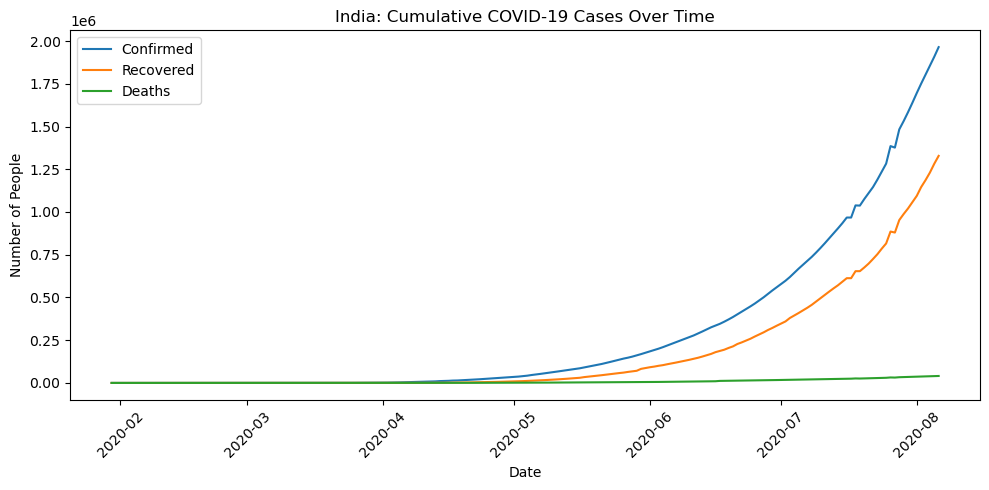

In [31]:
# Create the figure
plt.figure(figsize=(10, 5))

# Plot confirmed cases
plt.plot(
    national["date"],
    national["confirmed"],
    label="Confirmed"
)

# Plot recovered cases
plt.plot(
    national["date"],
    national["cured"],
    label="Recovered"
)

# Plot deaths
plt.plot(
    national["date"],
    national["deaths"],
    label="Deaths"
)

# Add title and labels
plt.title("India: Cumulative COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Number of People")

# Show legend
plt.legend()

# Rotate date labels
plt.xticks(rotation=45)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

# Chart 2 -> Daily New Confirmed Cases

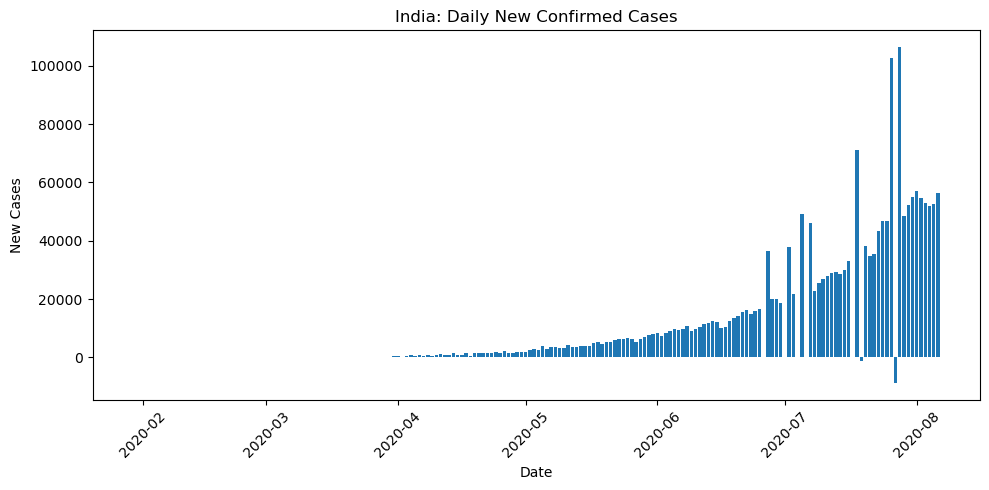

In [32]:
# Create the figure
plt.figure(figsize=(10, 5))

# Create a bar chart
plt.bar(
    national["date"],
    national["new_confirmed"]
)

# Add title and labels
plt.title("India: Daily New Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

# Chart 3 -> Top 10 States by Total Confirmed Cases

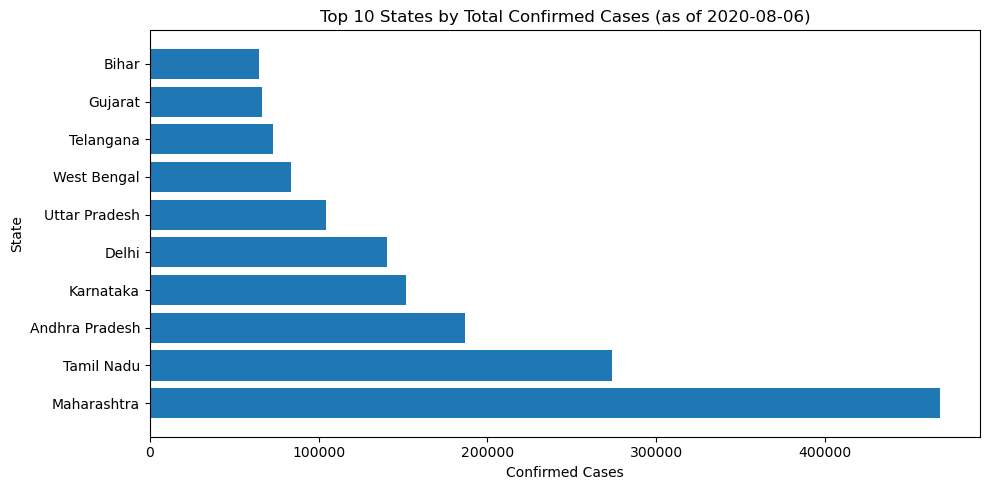

In [33]:
# Create the figure
plt.figure(figsize=(10, 5))

# Create a horizontal bar chart
plt.barh(
    top10["state"],
    top10["confirmed"]
)

plt.title(
    f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})"
)
plt.xlabel("Confirmed Cases")
plt.ylabel("State")

plt.tight_layout()
plt.show()

# Chart 4 -> Recovery Rate of the Top 10 Worst-Hit States

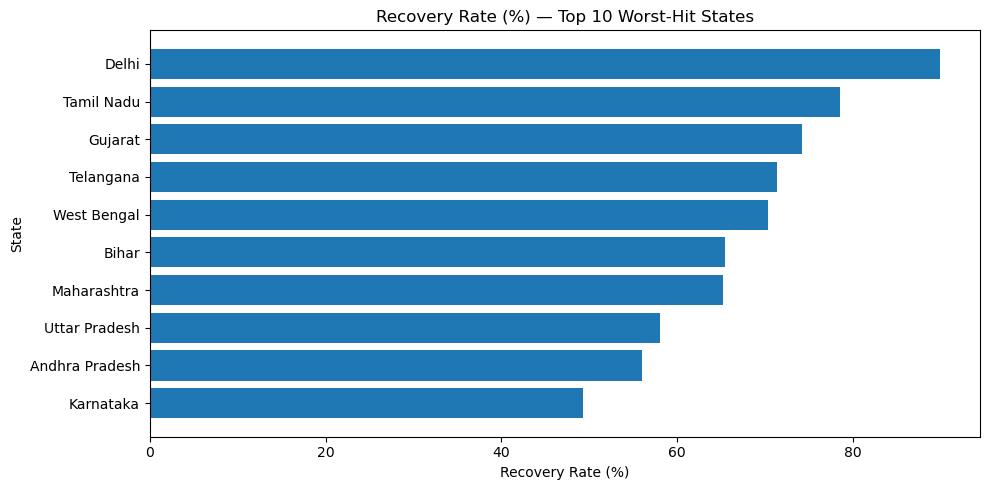

In [34]:
# Sort states by recovery rate
top10_sorted = top10.sort_values("recovery_rate")

# Create the figure
plt.figure(figsize=(10, 5))

# Create a horizontal bar chart
plt.barh(
    top10_sorted["state"],
    top10_sorted["recovery_rate"]
)

plt.title("Recovery Rate (%) — Top 10 Worst-Hit States")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

# Chart 5 -> Confirmed-Case Trend for the Top 5 States

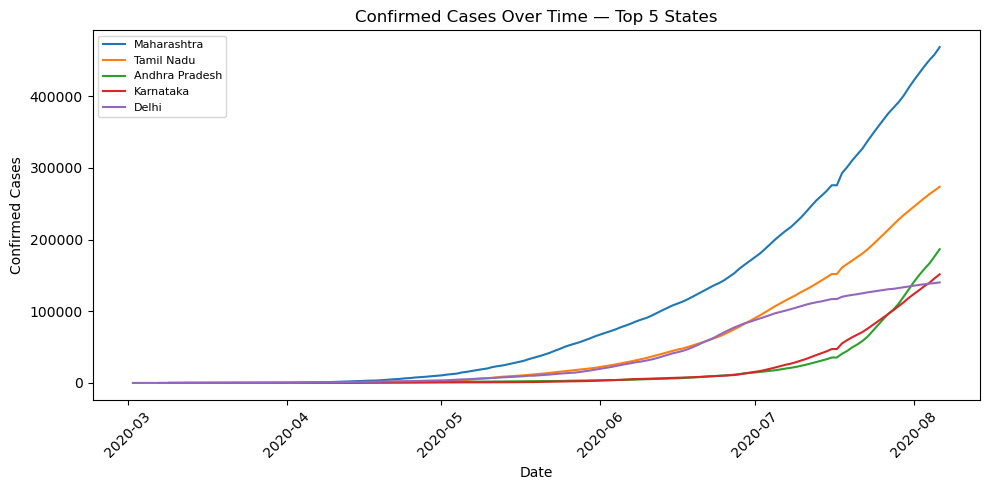

In [35]:
# Get the names of the top 5 states
top5_states = top10["state"].head(5).tolist()

# Create the figure
plt.figure(figsize=(10, 5))

# Plot confirmed cases for each state
for state in top5_states:
    state_data = cases[cases["state"] == state]

    plt.plot(
        state_data["date"],
        state_data["confirmed"],
        label=state
    )

plt.title("Confirmed Cases Over Time — Top 5 States")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend(fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 6 -> Share of National Cases by State

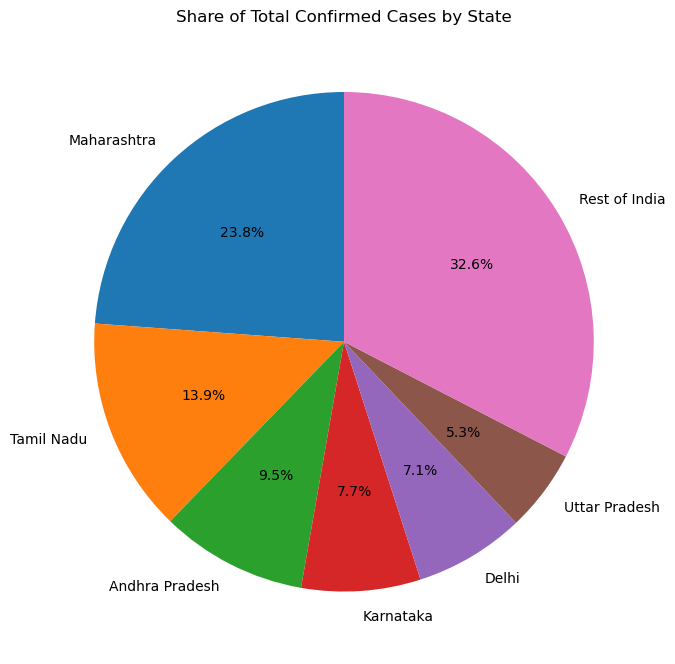

In [36]:
# Get the top 6 states by confirmed cases
top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]

# Calculate cases from all other states
others = latest["confirmed"].sum() - top6["confirmed"].sum()

# Create labels
pie_labels = top6["state"].tolist() + ["Rest of India"]

# Create values
pie_values = top6["confirmed"].tolist() + [others]

# Create the figure
plt.figure(figsize=(7, 7))

# Create the pie chart
plt.pie(
    pie_values,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Total Confirmed Cases by State")

plt.tight_layout()
plt.show()

# Chart 7 -> National Recovery-Rate Trend

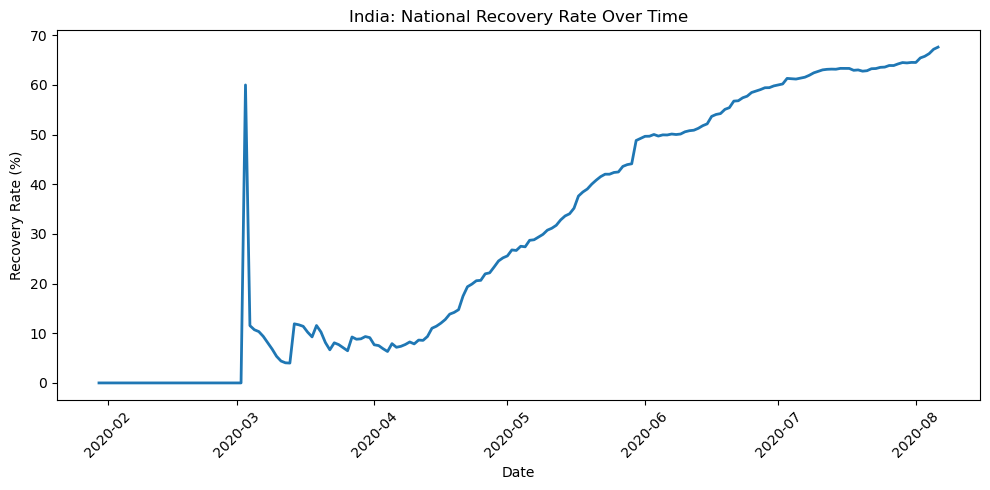

In [37]:
# Create the figure
plt.figure(figsize=(10, 5))

# Plot the recovery rate
plt.plot(
    national["date"],
    national["recovery_rate"],
    linewidth=2
)

plt.title("India: National Recovery Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Recovery Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 8 -> Recovery Rate vs Death Rate by State

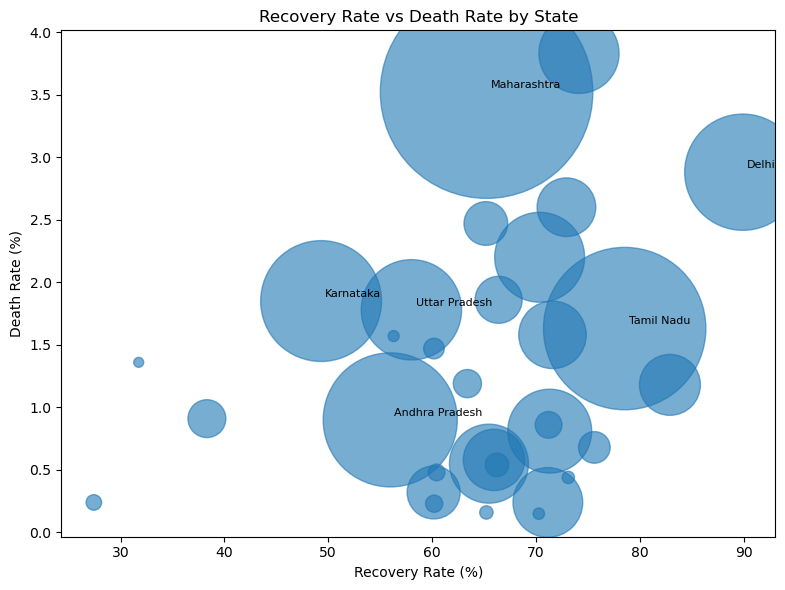

In [38]:
# Select states with at least 1,000 confirmed cases
sizeable = latest[latest["confirmed"] >= 1000]

# Create the figure
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(
    sizeable["recovery_rate"],
    sizeable["death_rate"],
    s=sizeable["confirmed"] / 20,
    alpha=0.6
)

# Label the top 6 states by confirmed cases
for _, row in sizeable.nlargest(6, "confirmed").iterrows():
    plt.annotate(
        row["state"],
        (row["recovery_rate"], row["death_rate"]),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points"
    )

plt.title("Recovery Rate vs Death Rate by State")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Death Rate (%)")

plt.tight_layout()
plt.show()

# Chart 9 -> Correlation Heatmap of National Metrics

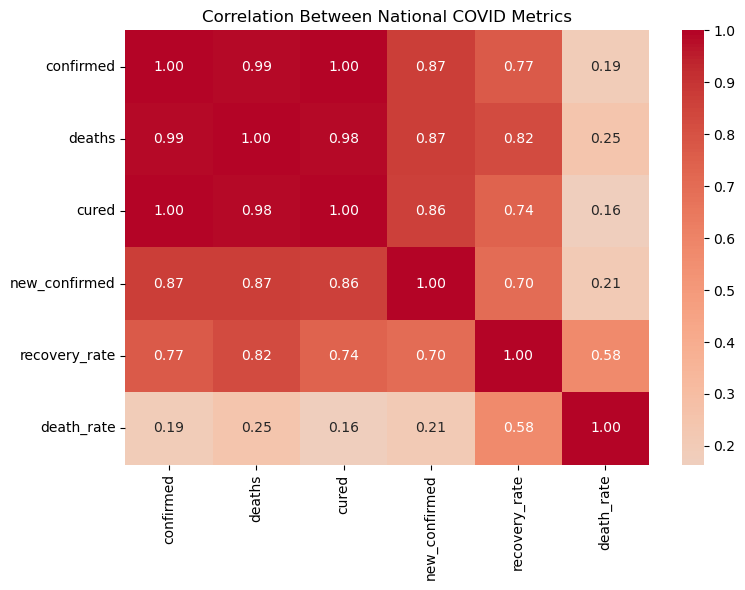

In [39]:
# Select the metrics for correlation analysis
corr_cols = [
    "confirmed",
    "deaths",
    "cured",
    "new_confirmed",
    "recovery_rate",
    "death_rate"
]

# Calculate the correlation matrix
corr = national[corr_cols].corr()

# Display the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between National COVID Metrics")

plt.tight_layout()
plt.show()

# Chart 10 -> Spread of Daily New Cases by Month

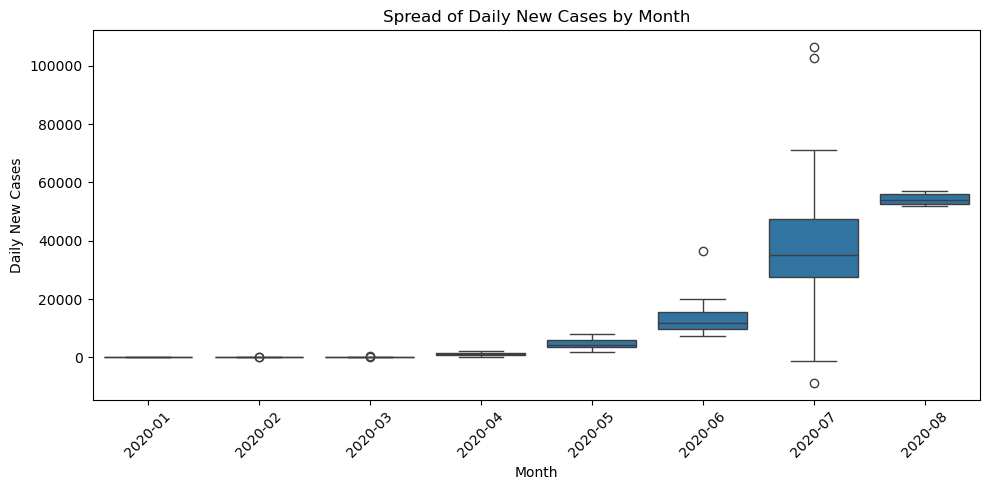

In [40]:
# Create a month column
national["month"] = national["date"].dt.strftime("%Y-%m")

# Create the figure
plt.figure(figsize=(10, 5))

# Create the boxplot
sns.boxplot(
    data=national,
    x="month",
    y="new_confirmed"
)

plt.title("Spread of Daily New Cases by Month")
plt.xlabel("Month")
plt.ylabel("Daily New Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 11 -> India's Vaccination Progress (2021–2024)

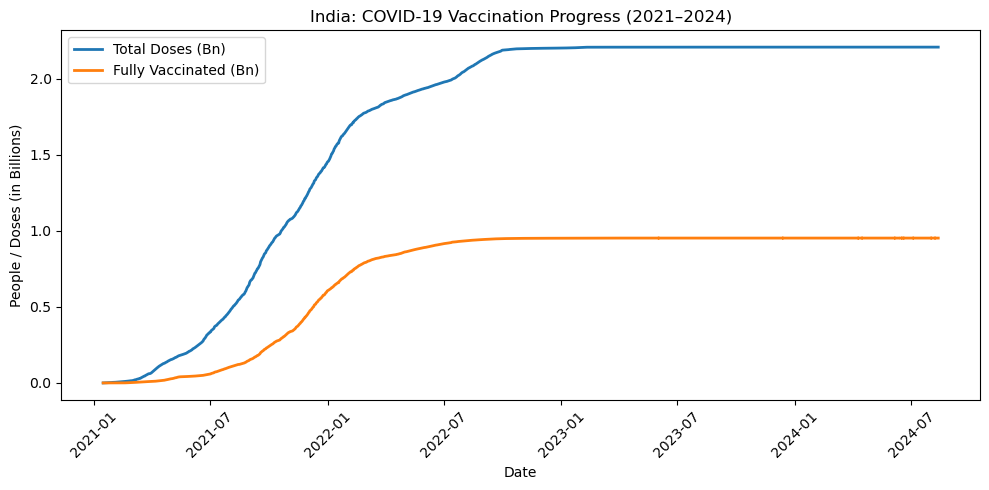

In [41]:
# Convert date column to datetime
vax["date"] = pd.to_datetime(vax["date"])

# Create the figure
plt.figure(figsize=(10, 5))

# Plot total vaccinations in billions
plt.plot(
    vax["date"],
    vax["total_vaccinations"] / 1e9,
    label="Total Doses (Bn)",
    linewidth=2
)

# Plot fully vaccinated people in billions
plt.plot(
    vax["date"],
    vax["people_fully_vaccinated"] / 1e9,
    label="Fully Vaccinated (Bn)",
    linewidth=2
)

plt.title("India: COVID-19 Vaccination Progress (2021–2024)")
plt.xlabel("Date")
plt.ylabel("People / Doses (in Billions)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 12 -> The 10 Least-Affected States/UTs

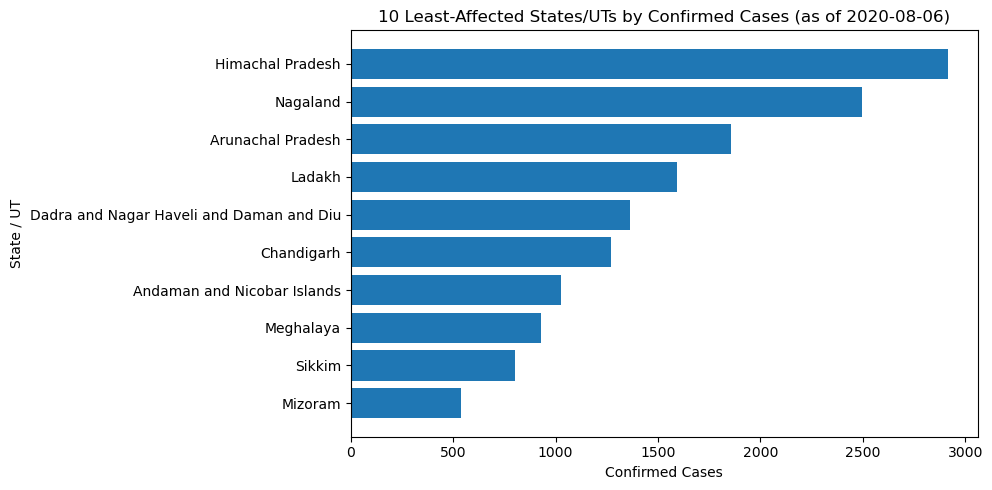

In [42]:
# Remove states with zero confirmed cases
positive_cases = latest[latest["confirmed"] > 0]

# Select the 10 states/UTs with the lowest confirmed cases
bottom10 = positive_cases.nsmallest(10, "confirmed")

# Create the figure
plt.figure(figsize=(10, 5))

# Create a horizontal bar chart
plt.barh(
    bottom10["state"],
    bottom10["confirmed"]
)

plt.title(
    f"10 Least-Affected States/UTs by Confirmed Cases "
    f"(as of {latest_date.date()})"
)
plt.xlabel("Confirmed Cases")
plt.ylabel("State / UT")

plt.tight_layout()
plt.show()

# 9. Save the cleaned dataset

In [43]:
# Save the cleaned data as a CSV file
cases.to_csv("cleaned_covid_india.csv",index=False)

# Display confirmation
print("Saved cleaned_covid_india.csv —",cases.shape[0],"rows.")

Saved cleaned_covid_india.csv — 4692 rows.
